In [12]:
!pip install ultralytics>=8.3.0

In [13]:
# If Ultralytics isn't installed yet, uncomment the next line:
# !pip install ultralytics torch torchvision torchaudio tabulate pandas opencv-python

import torch, platform, os, cv2, pandas as pd, numpy as np
from pathlib import Path

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", platform.python_version())

CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Python: 3.10.18


In [14]:
# === CONFIG ===
VIDEO_PATH = "CapturedDataset/IMG_7412.mp4"  # change this
OUT_DIR = "runs/assignment8_task1_nb"

# You can switch to s/m/l/x variants to explore accuracy/speed tradeoff.
MODELS = ["yolov8n.pt", "yolov11n.pt", "yolov12n.pt"]

IMGSZ = 640
CONF = 0.25
IOU  = 0.45
DEVICE = ""  # ""=auto; "0" for CUDA:0; "cpu" for CPU

# Create output directory
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

In [15]:
import time, csv
from statistics import mean
from ultralytics import YOLO

def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def _readable_size(num_bytes: float) -> str:
    for unit in ["B","KB","MB","GB"]:
        if num_bytes < 1024: return f"{num_bytes:.1f}{unit}"
        num_bytes /= 1024
    return f"{num_bytes:.1f}TB"

def benchmark_model(model_name: str,
                    video_path: Path,
                    out_dir: Path,
                    imgsz:int=640, conf:float=0.25, iou:float=0.45,
                    device:str=""):
    """
    Runs a YOLO model on one video, writes an annotated MP4 and per-frame CSV,
    and returns a dict of summary metrics.
    """
    model = YOLO(model_name)  # auto-downloads if not present
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    tag = Path(model_name).stem
    model_out = Path(out_dir) / tag
    _ensure_dir(model_out)
    out_mp4 = model_out / f"{tag}_annotated.mp4"
    out_csv = model_out / f"{tag}_detections.csv"

    fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    vw = cv2.VideoWriter(str(out_mp4), cv2.VideoWriter_fourcc(*"mp4v"), fps_in, (w,h))

    frame_times = []
    frame_dets  = []
    total_frames= 0

    # prepare CSV
    with open(out_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame","class_id","class_name","conf","x1","y1","x2","y2"])

    while True:
        ok, img = cap.read()
        if not ok:
            break
        total_frames += 1

        t0 = time.perf_counter()
        results = model.predict(img, imgsz=imgsz, conf=conf, iou=iou, device=device, verbose=False)
        dt = time.perf_counter() - t0
        frame_times.append(dt)

        res = results[0]
        annotated = res.plot()
        vw.write(annotated)

        # collect detections
        dets_count = 0
        boxes = res.boxes
        names = res.names if hasattr(res, "names") else model.names
        if boxes is not None and boxes.xyxy is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            clss = boxes.cls.cpu().numpy()
            confs= boxes.conf.cpu().numpy()
            dets_count = len(confs)

            with open(out_csv, "a", newline="") as f:
                writer = csv.writer(f)
                for (x1,y1,x2,y2), c, p in zip(xyxy, clss, confs):
                    cname = names.get(int(c), str(int(c))) if isinstance(names, dict) else str(int(c))
                    writer.writerow([total_frames, int(c), cname, float(p), float(x1), float(y1), float(x2), float(y2)])

        frame_dets.append(dets_count)

    cap.release()
    vw.release()

    avg_lat = mean(frame_times) * 1000.0 if frame_times else 0.0  # ms
    avg_fps = (1.0 / mean(frame_times)) if frame_times else 0.0
    total_dets = sum(frame_dets)

    # mean conf from CSV
    try:
        df = pd.read_csv(out_csv)
        mean_conf = float(df["conf"].mean()) if len(df) else 0.0
    except Exception:
        mean_conf = 0.0

    try:
        out_size = _readable_size(Path(out_mp4).stat().st_size)
    except Exception:
        out_size = "N/A"

    return {
        "model": model_name,
        "imgsz": imgsz,
        "conf": conf,
        "iou": iou,
        "device": device or ("cuda" if torch.cuda.is_available() else "cpu"),
        "video": str(video_path),
        "output_video": str(out_mp4),
        "detections_csv": str(out_csv),
        "frames": total_frames,
        "avg_latency_ms": avg_lat,
        "avg_fps": avg_fps,
        "total_detections": total_dets,
        "mean_conf": mean_conf,
        "annotated_video_size": out_size,
    }

In [16]:
video_path = Path(VIDEO_PATH)
assert video_path.exists(), f"Video not found: {video_path}"

# === FIX 1: normalize model names before running ===

def normalize_ultralytics_name(name: str) -> str:
    aliases = {
        "yolov11n.pt": "yolo11n.pt",
        "yolov11s.pt": "yolo11s.pt",
        "yolov11m.pt": "yolo11m.pt",
        "yolov11l.pt": "yolo11l.pt",
        "yolov11x.pt": "yolo11x.pt",
        "yolov12n.pt": "yolo12n.pt",
        "yolov12s.pt": "yolo12s.pt",
        "yolov12m.pt": "yolo12m.pt",
        "yolov12l.pt": "yolo12l.pt",
        "yolov12x.pt": "yolo12x.pt",
    }
    return aliases.get(name, name)

MODELS = [normalize_ultralytics_name(m) for m in MODELS]
print(MODELS)



# === FIX 2: safer run loop with try/except ===

rows = []
for m in MODELS:
    try:
        print(f"Running: {m}")
        metrics = benchmark_model(
            model_name=m,
            video_path=video_path,
            out_dir=Path(OUT_DIR),
            imgsz=IMGSZ, conf=CONF, iou=IOU, device=DEVICE
        )
        rows.append(metrics)
        print(f"  -> FPS: {metrics['avg_fps']:.2f} | Latency: {metrics['avg_latency_ms']:.1f} ms | "
              f"Dets: {metrics['total_detections']} | Mean conf: {metrics['mean_conf']:.3f}")
    except FileNotFoundError as e:
        print(f"  ⚠️ Skipping {m}: weights not found. ({e})")
    except Exception as e:
        print(f"  ⚠️ {m} failed: {e}")

print("Done.")

['yolov8n.pt', 'yolo11n.pt', 'yolo12n.pt']
Running: yolov8n.pt


  -> FPS: 201.99 | Latency: 5.0 ms | Dets: 664 | Mean conf: 0.699
Running: yolo11n.pt
  -> FPS: 171.46 | Latency: 5.8 ms | Dets: 717 | Mean conf: 0.847
Running: yolo12n.pt
  -> FPS: 128.19 | Latency: 7.8 ms | Dets: 821 | Mean conf: 0.831
Done.


In [17]:
summary_df = pd.DataFrame(rows)[[
    "model","imgsz","conf","iou","device",
    "frames","avg_fps","avg_latency_ms","total_detections","mean_conf",
    "output_video","detections_csv","annotated_video_size"
]]
display(summary_df)

summary_csv_path = Path(OUT_DIR) / "summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print("Saved:", summary_csv_path)

,model,imgsz,conf,iou,device,frames,avg_fps,avg_latency_ms,total_detections,mean_conf,output_video,detections_csv,annotated_video_size
0,yolov8n.pt,640,0.25,0.45,cuda,350,201.992066,4.950690,664,0.698999,runs/assignment8_task1_nb/yolov8n/yolov8n_anno...,runs/assignment8_task1_nb/yolov8n/yolov8n_dete...,22.3MB
1,yolo11n.pt,640,0.25,0.45,cuda,350,171.455412,5.832420,717,0.847085,runs/assignment8_task1_nb/yolo11n/yolo11n_anno...,runs/assignment8_task1_nb/yolo11n/yolo11n_dete...,22.1MB
2,yolo12n.pt,640,0.25,0.45,cuda,350,128.191008,7.800859,821,0.830680,runs/assignment8_task1_nb/yolo12n/yolo12n_anno...,runs/assignment8_task1_nb/yolo12n/yolo12n_dete...,21.6MB


Saved: runs/assignment8_task1_nb/summary.csv


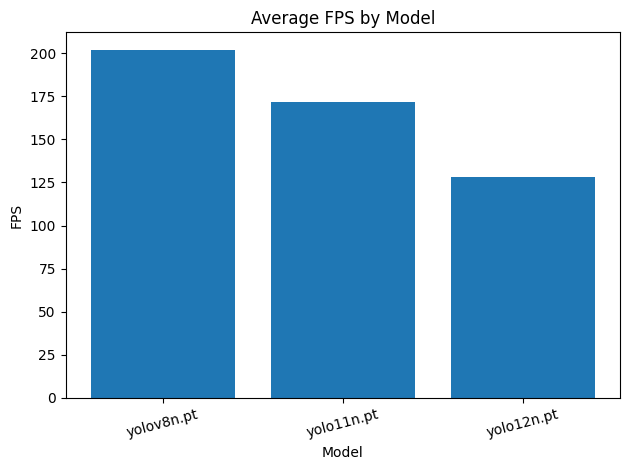

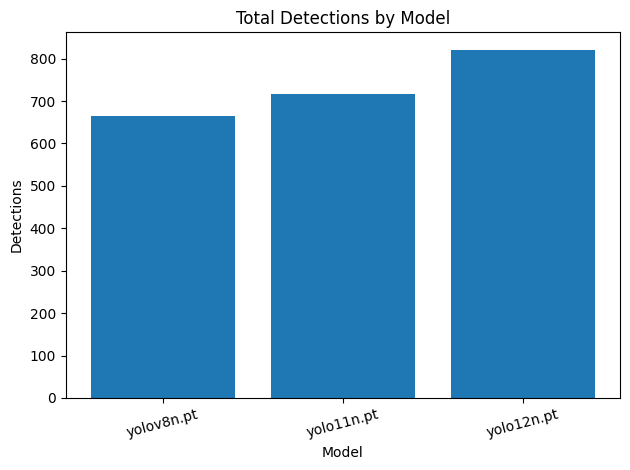

In [18]:
import matplotlib.pyplot as plt

# FPS
plt.figure()
plt.bar(summary_df["model"], summary_df["avg_fps"])
plt.title("Average FPS by Model")
plt.xlabel("Model")
plt.ylabel("FPS")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Total detections
plt.figure()
plt.bar(summary_df["model"], summary_df["total_detections"])
plt.title("Total Detections by Model")
plt.xlabel("Model")
plt.ylabel("Detections")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

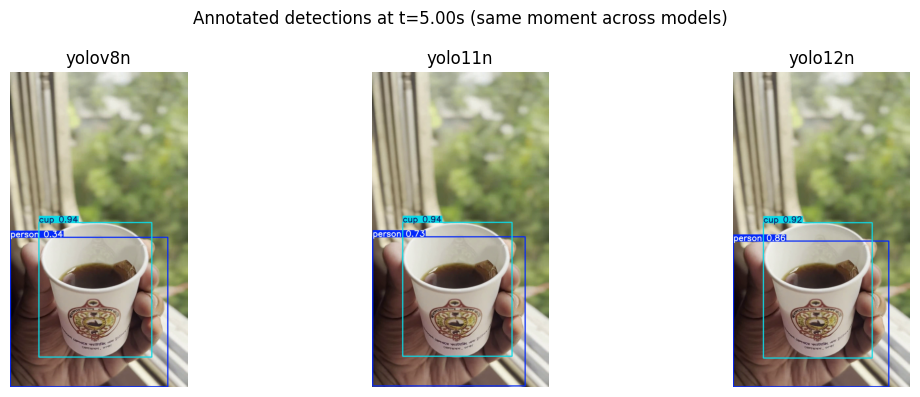

In [20]:
# Pick a timestamp (in seconds) to sample the SAME moment from each annotated video
SAMPLE_TIME_S = 5.0  # change if your clip is shorter/longer

import cv2, math
import matplotlib.pyplot as plt
from pathlib import Path

def read_frame_at_time(video_path: str, t_sec: float):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frame_id = int(round(t_sec * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not grab frame {frame_id} at {t_sec:.2f}s from {video_path}")
    # BGR -> RGB for matplotlib
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame

plt.figure(figsize=(12, 4))
for i, m in enumerate(MODELS, 1):
    tag = Path(m).stem
    vpath = Path(OUT_DIR) / tag / f"{tag}_annotated.mp4"
    frame = read_frame_at_time(str(vpath), SAMPLE_TIME_S)
    plt.subplot(1, len(MODELS), i)
    plt.imshow(frame)
    plt.axis('off')
    plt.title(tag)
plt.suptitle(f"Annotated detections at t={SAMPLE_TIME_S:.2f}s (same moment across models)")
plt.tight_layout()
plt.show()

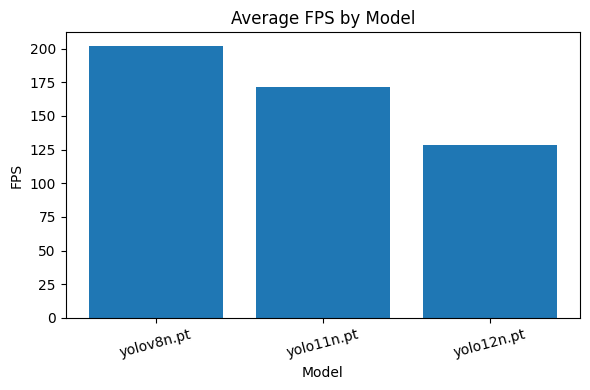

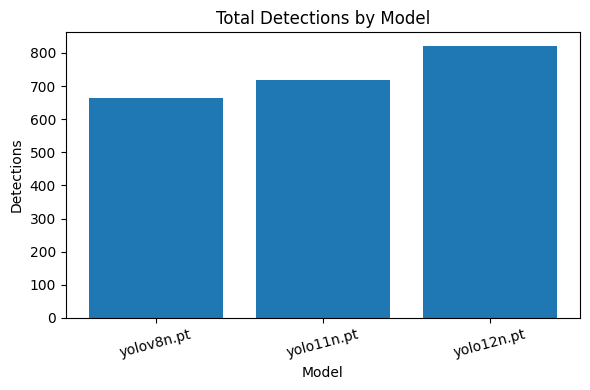

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure summary_df exists (from earlier)
if 'summary_df' in globals():
    # FPS
    plt.figure(figsize=(6,4))
    plt.bar(summary_df["model"], summary_df["avg_fps"])
    plt.title("Average FPS by Model")
    plt.xlabel("Model")
    plt.ylabel("FPS")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Detections
    plt.figure(figsize=(6,4))
    plt.bar(summary_df["model"], summary_df["total_detections"])
    plt.title("Total Detections by Model")
    plt.xlabel("Model")
    plt.ylabel("Detections")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("Run the summary table cell first to create `summary_df`.")